## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?

Regression predicts a continuous numerical value, such as price or temperature. Classification predicts a category or class, such as spam/not spam.

2. What is a confusion table? What does it help us understand about a model's performance?

A confusion table compares the model's predicted classes with the actual classes. It shows which classes the model predicts correctly and which classes it tends to confuse.

3. What does the SSE quantify about a particular model?

SSE (Sum of Squared Errors) measures the total squared difference between the actual values and predicted values. A lower SSE generally means the predictions are closer to the actual values.

4. What are overfitting and underfitting? 

Overfitting happens when a model learns the training data too closely, including noise, so it performs poorly on new data. Underfitting happens when a model is too simple to capture important patterns in the data.

5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?

The training set is used to build the model, while the testing set checks how well it performs on unseen data. Comparing different values of \(k\) helps us choose one that generalizes well instead of simply fitting the training data.

6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

A class label gives one clear prediction. It is simple and easy to interpret, but it does not tell us how confident the model is. 

A probability distribution might instead give something like 70% gold, 25% silver, and 5% bronze. This provides more information about the model's uncertainty and confidence, but it is more complicated to interpret and the probabilities may not always be well-calibrated.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Dylan Wang

**Date:** 9/27/2026

In [1]:
# Your Phase 1 solution to the problem goes here.

# import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv('data/land_mines.csv')
df.head(10)


,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1
5,0.240966,0.727273,0.0,1
6,0.254410,0.818182,0.0,1
7,0.234924,1.000000,0.0,1
8,0.353474,0.000000,0.6,1
9,0.335347,0.181818,0.6,1


In [2]:
# question 1:
print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nSummary statistics:")
display(df.describe())

print("\nMine type counts:")
print(df["mine_type"].value_counts().sort_index())

Shape: (338, 4)

Data types:
voltage      float64
height       float64
soil         float64
mine_type      int64
dtype: object

Missing values:
voltage      0
height       0
soil         0
mine_type    0
dtype: int64

Summary statistics:


,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000



Mine type counts:
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64


### EDA
The dataset contains 338 observations. The target variable is `mine_type`, 
which has five possible classes from 1 to 5. The three features used to predict 
mine type are `voltage`, `height`, and `soil`.

The five mine types are fairly evenly distributed, with each class containing 
between 65 and 71 observations. The features are all numerical and are already 
on similar scales between approximately 0 and 1.

In [3]:
# question 2:
X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5, # make them equal size 50 test 50 train
    random_state=42,
    stratify=y
)

print("Training size:", len(X_train))
print("Testing size:", len(X_test))

print("\nTraining class counts:")
print(y_train.value_counts().sort_index())

print("\nTesting class counts:")
print(y_test.value_counts().sort_index())

Training size: 169
Testing size: 169

Training class counts:
mine_type
1    35
2    35
3    33
4    33
5    33
Name: count, dtype: int64

Testing class counts:
mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64


I split the data 50/50 into training and testing sets. I used stratification 
based on `mine_type` so that each mine type has approximately the same 
proportion in both sets.

In [4]:
# question 3:
k_values = range(1, 31)
accuracies = []

# loop through each k value, train the model, and calculate accuracy
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)

    accuracies.append(accuracy)

# get the best k
best_k = k_values[np.argmax(accuracies)]

print("Best k:", best_k)
print("Best accuracy:", max(accuracies))


Best k: 2
Best accuracy: 0.4378698224852071


I tested values of k from 1 through 30 and compared their classification 
accuracy on the test set. The highest accuracy was obtained at k = 2, with 
an accuracy of about 43.8%. Therefore, I selected k = 2 for the final model.

In [5]:
# question 4:

best_model = KNeighborsClassifier(n_neighbors=best_k)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", round(accuracy * 100, 2), "%")

confusion = pd.crosstab(
    y_test,
    y_pred,
    rownames=["Actual"],
    colnames=["Predicted"]
)

confusion



Accuracy: 0.4378698224852071
Accuracy percentage: 43.79 %


Predicted,1,2,3,4,5
Actual,,,,,
1,25,0,6,4,1
2,0,32,0,3,0
3,12,2,9,6,4
4,12,5,8,8,0
5,15,2,10,5,0


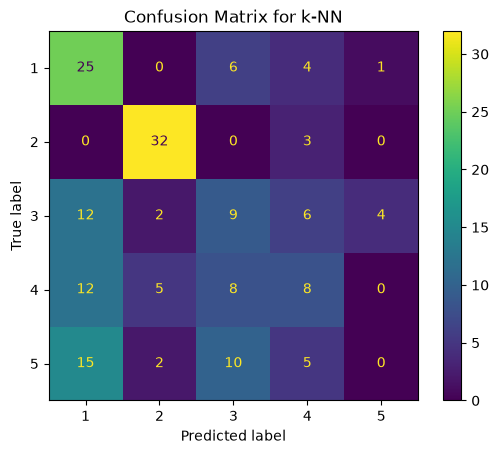

In [6]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Confusion Matrix for k-NN")
plt.show()

The final model has an accuracy of about 43.8%. However, its performance 
varies significantly between mine types.

Mine type 2 is predicted very well, with 32 of 35 examples classified 
correctly. Mine type 1 also performs relatively well, with 25 of 36 classified 
correctly.

The model performs much worse for types 3, 4, and especially 5. None of the 
type 5 observations in this test split were correctly predicted as type 5. 
Many type 5 mines were instead classified as types 1 or 3.

Therefore, the overall accuracy does not fully describe the model's performance 
for each individual class.

### question 5
I would not recommend using this model as the only method for identifying a 
mine in practice. It could be a baseline model. 

Although it performs well for some classes, it makes many mistakes for others. For example, in this test set it failed to correctly identify any type 5 mines.

This is quite important because mine identification is a safety-critical 
problem. A wrong prediction could be much more serious than an error in a 
typical classification problem.

Instead, I would use the model as a supporting tool. I would also collect 
more data and improve the model before considering it for real-world use.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** `15492d624dd4a25b46b23a20fde504806396d21a` (`finished phase 1`) 
- **AI tool and model used:** OpenAI Codex (GPT-6).
- **Revision scope:** evaluation and suggestions on phase 1

### *Prompts used

1. "review my code in phase 1, check if my code in phase one have fully satisfied the questions requirements, give suggestions and concrete modifications"

2. "elaborate on the code implementations and suggestions on question 1 wording"

### Phase 1 requirement review

**Overall:** Phase 1 addresses every numbered question. Its code and reported results are consistent. The main limitation is interpreting a tuning-set score as test performance, rather than missing an implementation requirement.

| Requirement | Assessment and concrete revision |
|---|---|
| Q1.1–Q1.4 | Correct definitions. Add the SSE formula and specify that comparisons require the same outcome scale and evaluation observations. |
| Q1.5 | Answers the assignment's intended holdout-selection procedure, but needs a caveat: the set used to select k is validation data. A separate untouched test set is needed for an independent final estimate. |
| Q1.6 | Correct strengths and weaknesses. Explain that KNN probabilities are neighbor vote fractions and may be poorly calibrated. |
| Q2.1 | Satisfied: dimensions, types, missingness, summary statistics, class counts, and narrative. Add plots and duplicate checks; treat numeric class codes as categories. |
| Q2.2 | Fully satisfied: 169/169 split, fixed seed, and stratification. |
| Q2.3 | Satisfied: searches k = 1 through 30 and selects k = 2. Explain the first/smallest-k tie rule and show the search curve. “Optimal” means best within this search and split. |
| Q2.4 | Satisfied: confusion table, plot, accuracy, and class-specific interpretation. Add precision/recall: type 1 has 25/36 recall but only 25/64 precision. |
| Q2.5 | Satisfied at a basic level. Connect the recommendations to false predicted labels as well as missed classes, and explicitly describe the uncertainty of neighbor votes. |

Keeping the original feature representation and holdout search makes the revision directly comparable to Phase 1. Further preprocessing or cross-validation would be possible extensions, rather than requirements missing from the original answer.

### *AI-proposed changes

1. Keep Phase 1 unchanged and clarify in Phase 2 that choosing k on the held-out half makes it a validation set; its selected accuracy is not an independent test estimate.
2. Expand EDA with feature distributions, class proportions, missing-value and duplicate checks, and an explicit explanation of the distance-scale assumption.
3. Retain the required stratified 50/50 split and k = 1 through 30 search; show the validation accuracy curve, document tie-breaking, and compare with a training-majority baseline.
4. Report a complete five-class confusion table, precision, recall, and F1, and distinguish correctly identifying actual mines from the reliability of predicted labels.
5. Strengthen the practical interpretation using observed error counts and explain why neighbor-vote probabilities do not establish reliable confidence.

### *Evaluation of AI suggestions

*AI-assisted evaluation draft, supported by the computations below; the student should review these decisions before submission.*

| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | Rename the tuning half validation data and qualify the score. This follows the assignment's test/validation wording without claiming an untouched test set. |
| 2 | Accept | Summaries and plots describe all three features and five labels. Check missingness and duplicates. Retain the original scales for comparison; similar ranges alone do not prove the best distance weighting. |
| 3 | Accept | Preserve the assignment's 50/50 design and reproducible split. The search reproduces k = 2 and 74/169 correct; a majority baseline gives 36/169. |
| 4 | Accept | Explicit labels retain even unpredicted classes. Row and column totals distinguish recall from precision; type 1 precision is only 25/64 despite recall of 25/36. |
| 5 | Accept | The confusion table shows 32 missed type 5 observations and five incorrect type 5 predictions. Probabilities at k = 2 have only three possible values per class and are not calibrated confidence. |

### *AI-assisted solution in full

### Q1: Conceptual questions

1. **Regression versus classification:** Regression predicts a continuous numerical outcome, such as temperature. Classification predicts a categorical outcome, such as mine type. Integer category labels do not make a task regression.
2. **Confusion table:** Rows represent actual labels and columns predicted labels. Diagonal entries count correct classifications; off-diagonal entries show specific confusions. Row proportions give class recall, while a diagonal entry divided by its column total gives class precision.
3. **SSE:** $\mathrm{SSE}=\sum_{i=1}^{n}(y_i-\hat y_i)^2$ measures total squared prediction error and penalizes large errors strongly. Lower SSE means closer predictions when evaluated on the same observations and outcome scale. Low training SSE alone does not establish generalization.
4. **Overfitting and underfitting:** Overfitting captures training noise and does not generalize well; underfitting misses relevant patterns. Very small k can have high variance, while very large k can smooth away useful class boundaries.
5. **Splitting and choosing k:** Training data provide neighbors, and validation data help select k using accuracy for classification or SSE for regression. This can improve generalization compared with choosing based on training performance, but improvement is not guaranteed. Once a held-out set is used to choose k, it is a validation set, even if called “test” in the assignment. Reporting the winning score on that same set can be optimistic. An untouched test set would be needed for an independent final estimate; cross-validation within training data is another way to tune k while reserving a test set.
6. **Labels versus probabilities:** A label is simple and supports a definite classification, but hides uncertainty and competing classes. A probability vector shows alternatives and can support decisions that account for different error costs, but is harder to interpret and may be poorly calibrated. With uniform-weight KNN, probabilities are fractions of neighbors voting for each class. At k = 2, each class receives 0, 0.5, or 1; unanimous neighbors are not proof of certainty.

Shape: (338, 4)


,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


,dtype
voltage,float64
height,float64
soil,float64
mine_type,int64


,missing
voltage,0
height,0
soil,0
mine_type,0


Exact duplicate rows: 0


,voltage,height,soil
count,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550
std,0.195819,0.306043,0.344244
min,0.197734,0.000000,0.000000
25%,0.309737,0.272727,0.200000
50%,0.359516,0.545455,0.600000
75%,0.482628,0.727273,0.800000
max,0.999999,1.000000,1.000000


,count,proportion
mine_type,,
1,71,0.210059
2,70,0.207101
3,66,0.195266
4,66,0.195266
5,65,0.192308


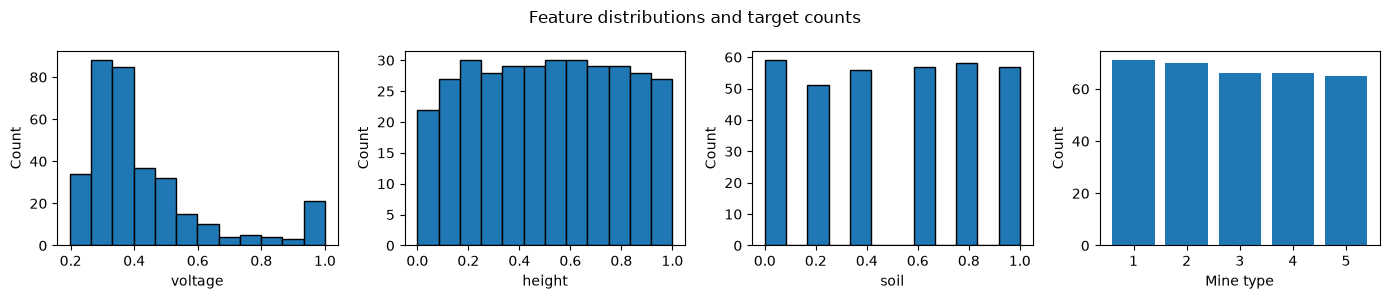

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# This section can run independently of Phase 1.
df = pd.read_csv("data/land_mines.csv")
features = ["voltage", "height", "soil"]
labels = [1, 2, 3, 4, 5]
print("Shape:", df.shape)
display(df.head())
display(df.dtypes.rename("dtype").to_frame())
display(df.isna().sum().rename("missing").to_frame())
print("Exact duplicate rows:", df.duplicated().sum())
display(df[features].describe())
class_counts = df["mine_type"].value_counts().reindex(labels, fill_value=0)
display(pd.DataFrame({"count": class_counts, "proportion": class_counts / len(df)}))
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, feature in zip(axes[:3], features):
    ax.hist(df[feature], bins=12, edgecolor="black")
    ax.set(xlabel=feature, ylabel="Count")
axes[3].bar(class_counts.index, class_counts.values)
axes[3].set(xlabel="Mine type", ylabel="Count", xticks=labels)
fig.suptitle("Feature distributions and target counts")
plt.tight_layout()
plt.show()

**Q2.1 interpretation:** There are 338 rows, three predictors, and five classes with counts 71, 70, 66, 66, and 65. There are no missing values or exact duplicate rows. Voltage ranges from about 0.198 to 1, and height and soil range from 0 to 1. Voltage has a median of about 0.360 below its mean of 0.431, suggesting right skew. Soil takes discrete encoded values; the CSV alone does not establish whether differences between its codes represent meaningful distances.

For direct comparison with Phase 1, retain these supplied feature scales and Euclidean distance. Although their ranges are similar, their variances differ, so equal ranges do not guarantee ideal feature weighting. Scaling or alternative soil encoding could be investigated with training-based validation and documentation of what soil codes mean. The class labels are categories, so their numeric mean is not a meaningful target summary.

In [8]:
# Q2.2: The held-out half is used for validation/model selection.
X = df[features]
y = df["mine_type"]
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)
print(f"Training size: {len(X_train)}; validation size: {len(X_val)}")
display(pd.DataFrame({
    "training": y_train.value_counts().reindex(labels),
    "validation": y_val.value_counts().reindex(labels)
}).rename_axis("mine_type"))

Training size: 169; validation size: 169


,training,validation
mine_type,,
1,35,36
2,35,35
3,33,33
4,33,33
5,33,32


The split contains 169 observations in each half. Stratification preserves approximate class proportions, and the fixed seed makes the comparison reproducible.

Selected k: 2
Selected validation accuracy: 43.79%
Training-majority baseline validation accuracy: 21.30%


,k,validation_accuracy
0,1,0.402367
1,2,0.437870
2,3,0.378698
3,4,0.355030
4,5,0.313609
5,6,0.325444
6,7,0.313609
7,8,0.307692
8,9,0.349112
9,10,0.337278


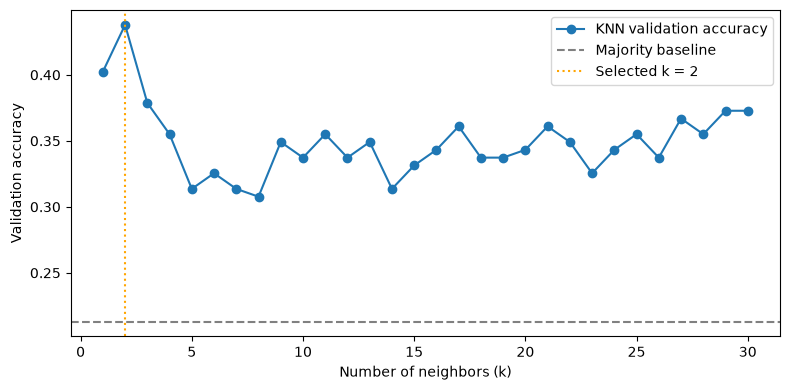

In [9]:
# Q2.3: Fixed candidate set, uniform voting, Euclidean distance.
k_values = np.arange(1, 31)
validation_scores = []
for k in k_values:
    candidate = KNeighborsClassifier(n_neighbors=int(k), weights="uniform", metric="euclidean")
    candidate.fit(X_train, y_train)
    validation_scores.append(accuracy_score(y_val, candidate.predict(X_val)))
search_results = pd.DataFrame({"k": k_values, "validation_accuracy": validation_scores})
# np.argmax returns the first maximum; ascending candidates favor smaller k on ties.
best_k = int(k_values[np.argmax(validation_scores)])
best_model = KNeighborsClassifier(n_neighbors=best_k, weights="uniform", metric="euclidean")
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_val)
baseline = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
baseline_accuracy = accuracy_score(y_val, baseline.predict(X_val))
print(f"Selected k: {best_k}")
print(f"Selected validation accuracy: {accuracy_score(y_val, y_pred):.2%}")
print(f"Training-majority baseline validation accuracy: {baseline_accuracy:.2%}")
display(search_results)
plt.figure(figsize=(8, 4))
plt.plot(k_values, validation_scores, marker="o", label="KNN validation accuracy")
plt.axhline(baseline_accuracy, color="gray", linestyle="--", label="Majority baseline")
plt.axvline(best_k, color="orange", linestyle=":", label=f"Selected k = {best_k}")
plt.xlabel("Number of neighbors (k)")
plt.ylabel("Validation accuracy")
plt.legend()
plt.tight_layout()
plt.show()

Among k = 1 through 30, k = 2 gives the highest validation accuracy, 43.79% (74/169), compared with 21.30% (36/169) for the training-majority baseline. This is the best model **within the specified search on this split**, not a globally optimal classifier. Because the same validation labels selected k and supplied this score, 43.79% is not an independent test estimate. At k = 2, class-vote ties can occur; scikit-learn's uniform voting selects the first tied class in its sorted class order, which can favor smaller labels.

Predicted,1,2,3,4,5
Actual,,,,,
1,25,0,6,4,1
2,0,32,0,3,0
3,12,2,9,6,4
4,12,5,8,8,0
5,15,2,10,5,0


Correct: 74/169; accuracy: 43.79%


,precision,recall,f1-score,support
1,0.390625,0.694444,0.500000,36.0
2,0.780488,0.914286,0.842105,35.0
3,0.272727,0.272727,0.272727,33.0
4,0.307692,0.242424,0.271186,33.0
5,0.000000,0.000000,0.000000,32.0


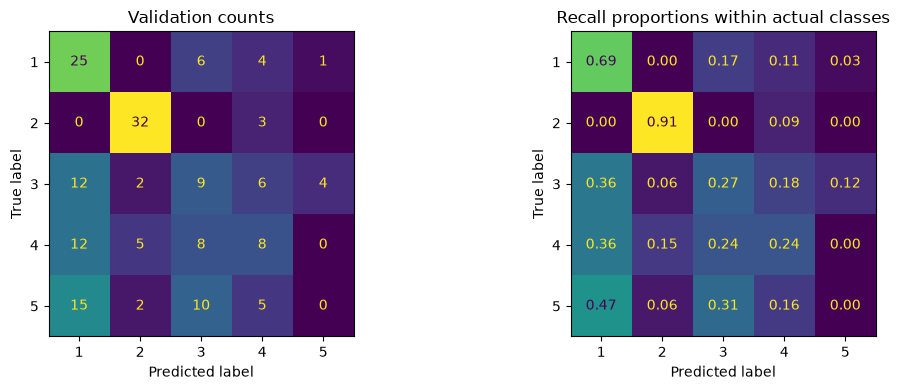

In [10]:
# Q2.4: Keep every class visible and distinguish precision from recall.
cm = confusion_matrix(y_val, y_pred, labels=labels)
confusion_table = pd.DataFrame(cm, index=labels, columns=labels)
confusion_table.index.name = "Actual"
confusion_table.columns.name = "Predicted"
display(confusion_table)
print(f"Correct: {np.trace(cm)}/{cm.sum()}; accuracy: {accuracy_score(y_val, y_pred):.2%}")
report = classification_report(y_val, y_pred, labels=labels, output_dict=True, zero_division=0)
class_metrics = pd.DataFrame(report).T.loc[[str(label) for label in labels]]
display(class_metrics)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Validation counts")
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred, labels=labels, normalize="true", values_format=".2f",
    ax=axes[1], colorbar=False
)
axes[1].set_title("Recall proportions within actual classes")
plt.tight_layout()
plt.show()

**Q2.4 interpretation:** Type 2 has the highest recall, 32/35 = 91.43%, and precision, 32/41 = 78.05%. Type 1 has recall 25/36 = 69.44%, but precision only 25/64 = 39.06%: 39 of the 64 type 1 predictions are wrong. Types 3 and 4 have recall 9/33 = 27.27% and 8/33 = 24.24%, respectively. Type 5 recall is 0/32; 15 actual type 5 observations are predicted as type 1 and 10 as type 3. All five predictions of type 5 are actually type 1 or 3. Thus, counting correct predictions alone can conceal substantial false positives and missed classes.

**Q2.5 practical interpretation:** These results support treating this as an exploratory baseline. Its labels are too unreliable to determine a mine's identity or safety on their own. Even the strongest class has nine false type 2 predictions, and every actual type 5 observation is missed. Any potential use would require independent expert assessment and validated procedures rather than action based solely on the predicted label. Additional representative data, information about feature encoding, and evaluation on independent data would be needed to assess usefulness. Overall accuracy should be supplemented by class-specific error rates and the consequences of each error. A high neighbor-vote probability is insufficient reassurance, especially with only two neighbors; any confidence-based deferral rule would itself need validation.

### *Reflection on AI assistance

AI is a very useful tool for coding, but I think it works best as an assistant rather than something that replaces our own thinking. I often use AI to explain unfamiliar concepts, debug errors, suggest different approaches, or help me understand why my code is not working. It can also save a lot of time when writing repetitive code or learning a new framework. However, AI also has some major shortcomings. It can generate code that looks correct but contains logical errors, security issues, or inefficient solutions. It also does not always understand the full context of a project. Relying on it too much can make us worse at solving problems independently, especially if we copy code without understanding it. The best way to use AI is to treat its output as a suggestion. We should still read the code, understand how it works, test it ourselves, and make the final decisions.